# Data Preprocessing and Baseline MLP — Steel Plates Faults

The goal of this notebook is to prepare the Steel Plates Faults dataset for later neural network classification.

The preprocessing focuses on:
- loading and cleaning the dataset
- separating features and target
- train/validation/test split
- checking split balance
- removal of constant and perfectly redundant features
- detection of binary and continuous variables
- transformation of strongly skewed variables
- normalization of continuous features
- encoding target labels
- final validation of processed data

The preprocessing decisions are based on the findings from the exploratory data analysis. Since the later model will be an MLP, particular attention is given to scaling and distribution shape of the input features.

In [28]:
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.io import arff

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

## Load the dataset

In [56]:
dataset_path = Path("../dataset/php9xWOpn.arff")

data, meta = arff.loadarff(dataset_path)
df = pd.DataFrame(data)


print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1941 entries, 0 to 1940
Data columns (total 34 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      1941 non-null   float64
 1   V2      1941 non-null   float64
 2   V3      1941 non-null   float64
 3   V4      1941 non-null   float64
 4   V5      1941 non-null   float64
 5   V6      1941 non-null   float64
 6   V7      1941 non-null   float64
 7   V8      1941 non-null   float64
 8   V9      1941 non-null   float64
 9   V10     1941 non-null   float64
 10  V11     1941 non-null   float64
 11  V12     1941 non-null   float64
 12  V13     1941 non-null   float64
 13  V14     1941 non-null   float64
 14  V15     1941 non-null   float64
 15  V16     1941 non-null   float64
 16  V17     1941 non-null   float64
 17  V18     1941 non-null   float64
 18  V19     1941 non-null   float64
 19  V20     1941 non-null   float64
 20  V21     1941 non-null   float64
 21  V22     1941 non-null   float64
 22  V23     194

Convert `Class` column from object to string.

In [30]:
df["Class"] = df["Class"].apply(lambda x: x.decode("utf-8") if isinstance(x, bytes) else x).astype("string")
print(df["Class"].dtype)

string


## Description of the dataframe

In [31]:
print(df.head())
print(df.shape)
print(df.columns.tolist())
print(df["Class"].value_counts())

       V1      V2         V3         V4      V5    V6     V7        V8    V9  \
0    42.0    50.0   270900.0   270944.0   267.0  17.0   44.0   24220.0  76.0   
1   645.0   651.0  2538079.0  2538108.0   108.0  10.0   30.0   11397.0  84.0   
2   829.0   835.0  1553913.0  1553931.0    71.0   8.0   19.0    7972.0  99.0   
3   853.0   860.0   369370.0   369415.0   176.0  13.0   45.0   18996.0  99.0   
4  1289.0  1306.0   498078.0   498335.0  2409.0  60.0  260.0  246930.0  37.0   

     V10  ...     V25     V26     V27  V28  V29  V30  V31  V32  V33  Class  
0  108.0  ...  0.8182 -0.2913  0.5822  1.0  0.0  0.0  0.0  0.0  0.0      1  
1  123.0  ...  0.7931 -0.1756  0.2984  1.0  0.0  0.0  0.0  0.0  0.0      1  
2  125.0  ...  0.6667 -0.1228  0.2150  1.0  0.0  0.0  0.0  0.0  0.0      1  
3  126.0  ...  0.8444 -0.1568  0.5212  1.0  0.0  0.0  0.0  0.0  0.0      1  
4  126.0  ...  0.9338 -0.1992  1.0000  1.0  0.0  0.0  0.0  0.0  0.0      1  

[5 rows x 34 columns]
(1941, 34)
['V1', 'V2', 'V3', 'V4'

## Separate features and target

The original dataset includes six binary fault-indicator columns (`V28`-`V33`). Since `Class` is derived from those indicators in this version of the dataset, they must be removed from the feature matrix to avoid target leakage.

In [32]:
leakage_cols = ["V28", "V29", "V30", "V31", "V32", "V33"]
X = df.drop(columns=["Class", *leakage_cols]).copy()
y = df["Class"].copy()

print("Removed leakage columns:", leakage_cols)
print(X.shape)
print(y.shape)

Removed leakage columns: ['V28', 'V29', 'V30', 'V31', 'V32', 'V33']
(1941, 27)
(1941,)


## Split the data into train, validation, and test sets

The dataset is split before any transformation so that all preprocessing steps can be fitted only on the training set and then applied to validation and test data. This prevents data leakage.

In [33]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Train shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_val.shape, y_val.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (1358, 27) (1358,)
Validation shape: (291, 27) (291,)
Test shape: (292, 27) (292,)


## Check class distribution after split

In [34]:
print("Train class distribution")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))

print("\nValidation class distribution")
print(y_val.value_counts())
print(y_val.value_counts(normalize=True))

print("\nTest class distribution")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True))

Train class distribution
Class
1    887
2    471
Name: count, dtype: Int64
Class
1    0.653166
2    0.346834
Name: proportion, dtype: Float64

Validation class distribution
Class
1    190
2    101
Name: count, dtype: Int64
Class
1    0.652921
2    0.347079
Name: proportion, dtype: Float64

Test class distribution
Class
1    191
2    101
Name: count, dtype: Int64
Class
1    0.65411
2    0.34589
Name: proportion, dtype: Float64


### Conclusion

The class distributions in the training, validation, and test sets remain very similar due to stratified splitting. This ensures that all subsets preserve the original class proportions and can be compared more fairly during later modeling and evaluation.

## Check missing values in each split

In [35]:
print("Missing values in training set")
print(X_train.isnull().sum().sort_values(ascending=False).head(10))

print("\nMissing values in validation set")
print(X_val.isnull().sum().sort_values(ascending=False).head(10))

print("\nMissing values in test set")
print(X_test.isnull().sum().sort_values(ascending=False).head(10))

Missing values in training set
V1     0
V2     0
V3     0
V4     0
V5     0
V6     0
V7     0
V8     0
V9     0
V10    0
dtype: int64

Missing values in validation set
V1     0
V2     0
V3     0
V4     0
V5     0
V6     0
V7     0
V8     0
V9     0
V10    0
dtype: int64

Missing values in test set
V1     0
V2     0
V3     0
V4     0
V5     0
V6     0
V7     0
V8     0
V9     0
V10    0
dtype: int64


### Conclusion

The split datasets do not show any missing-value issues. Therefore, no imputation step is required in the preprocessing pipeline.

## Remove perfectly redundant features

The EDA showed that some variables are perfectly or almost perfectly redundant. For the initial preprocessing, only perfectly correlated features are removed.

In [37]:
corr = X_train.corr(numeric_only=True).abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

perfect_corr_cols = [col for col in upper.columns if any(np.isclose(upper[col], 1.0))]

X_train = X_train.drop(columns=perfect_corr_cols)
X_val = X_val.drop(columns=perfect_corr_cols)
X_test = X_test.drop(columns=perfect_corr_cols)

print("Removed perfectly correlated columns:", perfect_corr_cols)
print("Remaining number of features:", X_train.shape[1])

Removed perfectly correlated columns: ['V4', 'V13']
Remaining number of features: 25


### Conclusion

Perfectly redundant variables are removed to reduce duplicated information in the feature space. This simplifies the input representation without losing meaningful predictive content.

## Separate binary and continuous features

The EDA indicated that several variables behave like binary or sparse indicator variables, while others are continuous. These groups should be treated differently during preprocessing.

In [38]:
binary_cols = [
    col for col in X_train.columns
    if set(pd.Series(X_train[col]).dropna().unique()).issubset({0, 1})
]

continuous_cols = [col for col in X_train.columns if col not in binary_cols]

print("Binary columns:", binary_cols)
print("Number of binary columns:", len(binary_cols))
print("Continuous columns:", continuous_cols)
print("Number of continuous columns:", len(continuous_cols))

Binary columns: ['V12']
Number of binary columns: 1
Continuous columns: ['V1', 'V2', 'V3', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27']
Number of continuous columns: 24


### Conclusion

The features can be divided into binary indicator variables and continuous numerical variables. This distinction is important because binary variables should generally remain unchanged, while continuous variables may require transformation and scaling.

## Detect strongly right-skewed continuous variables

The EDA showed that several continuous variables are strongly right-skewed. To reduce skewness and the influence of extreme large values, a `log1p` transformation is applied to strongly skewed non-negative continuous features.

In [39]:
skewness = X_train[continuous_cols].skew()

skewed_cols = [
    col for col in continuous_cols
    if (X_train[col] >= 0).all() and skewness[col] > 1
]

print("Skewed continuous columns selected for log1p transformation:", skewed_cols)

Skewed continuous columns selected for log1p transformation: ['V3', 'V5', 'V6', 'V7', 'V8', 'V10', 'V14', 'V18']


### Conclusion

Only strongly right-skewed continuous variables with non-negative values are selected for log transformation. This keeps the preprocessing targeted and avoids applying unnecessary transformations to all variables.

## Apply log transformation to selected columns

In [40]:
X_train = X_train.copy()
X_val = X_val.copy()
X_test = X_test.copy()

for col in skewed_cols:
    X_train[col] = np.log1p(X_train[col])
    X_val[col] = np.log1p(X_val[col])
    X_test[col] = np.log1p(X_test[col])

print("Log-transformed columns:", skewed_cols)

Log-transformed columns: ['V3', 'V5', 'V6', 'V7', 'V8', 'V10', 'V14', 'V18']


### Conclusion

The `log1p` transformation compresses extreme large values and makes the selected feature distributions less skewed, which is beneficial for later neural network training.

## Normalize continuous features

Since MLPs are sensitive to feature scale, continuous variables are standardized using `StandardScaler`. The scaler is fitted only on the training set and then applied to validation and test sets.

In [41]:
scaler = StandardScaler()

X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_val[continuous_cols] = scaler.transform(X_val[continuous_cols])
X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])

print(X_train[continuous_cols].describe().T[["mean", "std"]].head())

            mean       std
V1  8.894865e-17  1.000368
V2 -1.569682e-17  1.000368
V3 -1.778319e-15  1.000368
V5  2.092909e-16  1.000368
V6 -1.935941e-16  1.000368


### Conclusion

Continuous variables are standardized so that they have comparable scale. This improves optimization stability and helps prevent variables with large ranges from dominating the learning process.

## Convert feature matrices to float32

In [42]:
X_train = X_train.astype(np.float32)
X_val = X_val.astype(np.float32)
X_test = X_test.astype(np.float32)

print(X_train.dtypes.value_counts())

float32    25
Name: count, dtype: int64


### Conclusion

The processed feature matrices are converted to `float32`, which is the standard numerical type used in most neural network frameworks.

## Encode target labels

The target labels are converted from strings to numeric values so that they can be used in classification models.

In [43]:
label_encoder = LabelEncoder()

y_train_enc = label_encoder.fit_transform(y_train)
y_val_enc = label_encoder.transform(y_val)
y_test_enc = label_encoder.transform(y_test)

print("Class mapping:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))
print("Encoded training labels shape:", y_train_enc.shape)

Class mapping: {'1': np.int64(0), '2': np.int64(1)}
Encoded training labels shape: (1358,)


### Conclusion

The class labels are successfully encoded into numeric form. This makes the target variable compatible with later model training and evaluation.

## Final validation of processed data

In [44]:
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train_enc.shape)
print("y_val shape:", y_val_enc.shape)
print("y_test shape:", y_test_enc.shape)

print("NaNs in X_train:", np.isnan(X_train.to_numpy()).sum())
print("NaNs in X_val:", np.isnan(X_val.to_numpy()).sum())
print("NaNs in X_test:", np.isnan(X_test.to_numpy()).sum())

print("NaNs in y_train:", np.isnan(y_train_enc).sum())
print("NaNs in y_val:", np.isnan(y_val_enc).sum())
print("NaNs in y_test:", np.isnan(y_test_enc).sum())

X_train shape: (1358, 25)
X_val shape: (291, 25)
X_test shape: (292, 25)
y_train shape: (1358,)
y_val shape: (291,)
y_test shape: (292,)
NaNs in X_train: 0
NaNs in X_val: 0
NaNs in X_test: 0
NaNs in y_train: 0
NaNs in y_val: 0
NaNs in y_test: 0


## Final preprocessing conclusion

The preprocessing pipeline prepared the Steel Plates Faults dataset for later neural network classification. The data was first split into training, validation, and test sets using stratified sampling to preserve the original class proportions and to avoid data leakage.

No major missing-value issues were found, so no imputation was needed. Constant features were removed because they do not contribute useful predictive information. Perfectly redundant variables were also removed to reduce duplicated information in the feature space.

The remaining variables were divided into binary and continuous groups. Strongly right-skewed non-negative continuous features were transformed using `log1p` in order to reduce skewness and the impact of extreme values. Continuous variables were then standardized using `StandardScaler`, while binary variables were left unchanged.

Finally, the feature matrices were converted to `float32` format and the target labels were encoded into numeric form. The resulting processed datasets are now ready for baseline MLP training and later experiments.

## Baseline MLP — imports and reproducibility

This section defines the neural network baseline for the preprocessed Steel Plates Faults dataset.

A simple multilayer perceptron is used as the first neural baseline because:
- the dataset is tabular and already numerically encoded
- continuous variables have been standardized
- binary variables remain in a suitable format
- the target is multiclass

The baseline uses:
- two hidden layers
- ReLU activations
- dropout for regularization
- Adam optimizer
- class-weighted cross-entropy loss
- early stopping based on validation loss

In [45]:
import copy
import random

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


cpu


## Convert processed data into PyTorch datasets

The processed NumPy or pandas outputs are converted into tensors and wrapped into dataloaders for mini-batch training.

In [46]:
X_train_tensor = torch.tensor(X_train.to_numpy(), dtype=torch.float32)
X_val_tensor = torch.tensor(X_val.to_numpy(), dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.to_numpy(), dtype=torch.float32)

y_train_tensor = torch.tensor(y_train_enc, dtype=torch.long)
y_val_tensor = torch.tensor(y_val_enc, dtype=torch.long)
y_test_tensor = torch.tensor(y_test_enc, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

input_dim = X_train_tensor.shape[1]
num_classes = len(np.unique(y_train_enc))

print(input_dim)
print(num_classes)

25
2


## Define the baseline MLP architecture

The model uses two dense hidden layers. This is large enough to learn nonlinear structure, but still simple enough to serve as a baseline.

In [47]:
class BaselineMLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.net(x)

model = BaselineMLP(input_dim=input_dim, num_classes=num_classes).to(device)
print(model)

BaselineMLP(
  (net): Sequential(
    (0): Linear(in_features=25, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=2, bias=True)
  )
)


## Define loss function and optimizer

Because the target classes are not perfectly balanced, class weights are included in the cross-entropy loss.

In [48]:
class_counts = np.bincount(y_train_enc)
class_weights = len(y_train_enc) / (len(class_counts) * class_counts)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

print(class_counts)
print(class_weights)

[887 471]
[0.76550169 1.44161359]


## Training and evaluation functions

The following helper functions compute:
- average loss
- accuracy
- macro F1 score

Macro F1 is included because it gives a fairer picture across multiple classes.

In [49]:
def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None

    if training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    all_preds = []
    all_targets = []

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        if training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(training):
            logits = model(xb)
            loss = criterion(logits, yb)

            if training:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * xb.size(0)
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_targets.extend(yb.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_targets, all_preds)
    macro_f1 = f1_score(all_targets, all_preds, average="macro")

    return avg_loss, acc, macro_f1

## Train the baseline MLP

Early stopping is used to prevent overfitting. The best model is selected according to validation loss.

In [50]:
epochs = 100
patience = 15

history = {
    "train_loss": [],
    "train_acc": [],
    "train_f1": [],
    "val_loss": [],
    "val_acc": [],
    "val_f1": [],
}

best_val_loss = float("inf")
best_state = None
epochs_without_improvement = 0

for epoch in range(1, epochs + 1):
    train_loss, train_acc, train_f1 = run_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc, val_f1 = run_epoch(model, val_loader, criterion)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["train_f1"].append(train_f1)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    print(
        f"Epoch {epoch:03d} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} train_f1={train_f1:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} val_f1={val_f1:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print("Early stopping triggered.")
        break

model.load_state_dict(best_state)

Epoch 001 | train_loss=0.6493 train_acc=0.5825 train_f1=0.5621 | val_loss=0.5995 val_acc=0.5430 val_f1=0.5387
Epoch 002 | train_loss=0.5942 train_acc=0.5862 train_f1=0.5858 | val_loss=0.5771 val_acc=0.6529 val_f1=0.6462
Epoch 003 | train_loss=0.5632 train_acc=0.6848 train_f1=0.6702 | val_loss=0.5669 val_acc=0.6770 val_f1=0.6589
Epoch 004 | train_loss=0.5489 train_acc=0.7077 train_f1=0.6887 | val_loss=0.5551 val_acc=0.6907 val_f1=0.6661
Epoch 005 | train_loss=0.5343 train_acc=0.7172 train_f1=0.7006 | val_loss=0.5547 val_acc=0.6907 val_f1=0.6647
Epoch 006 | train_loss=0.5293 train_acc=0.7364 train_f1=0.7200 | val_loss=0.5484 val_acc=0.7010 val_f1=0.6628
Epoch 007 | train_loss=0.5129 train_acc=0.7585 train_f1=0.7393 | val_loss=0.5415 val_acc=0.7148 val_f1=0.6915
Epoch 008 | train_loss=0.4974 train_acc=0.7629 train_f1=0.7464 | val_loss=0.5356 val_acc=0.7251 val_f1=0.6967
Epoch 009 | train_loss=0.4957 train_acc=0.7570 train_f1=0.7433 | val_loss=0.5360 val_acc=0.7320 val_f1=0.7029
Epoch 010 

<All keys matched successfully>

## Plot training history

These curves help assess whether the model is learning effectively and whether overfitting appears.

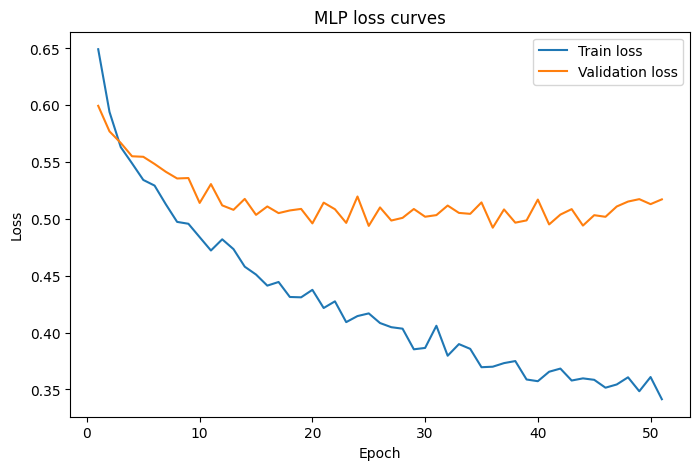

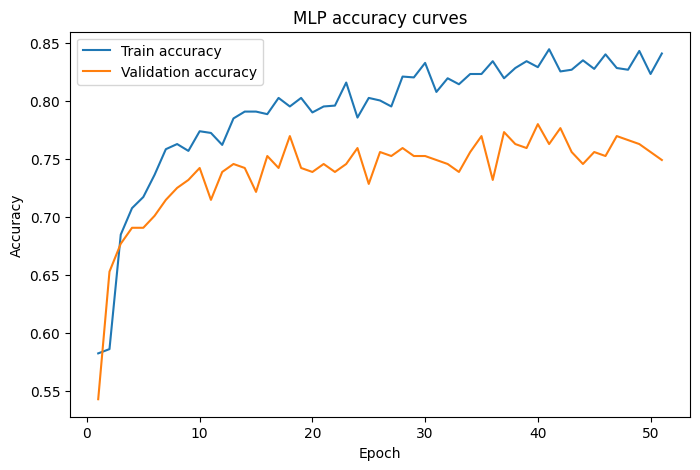

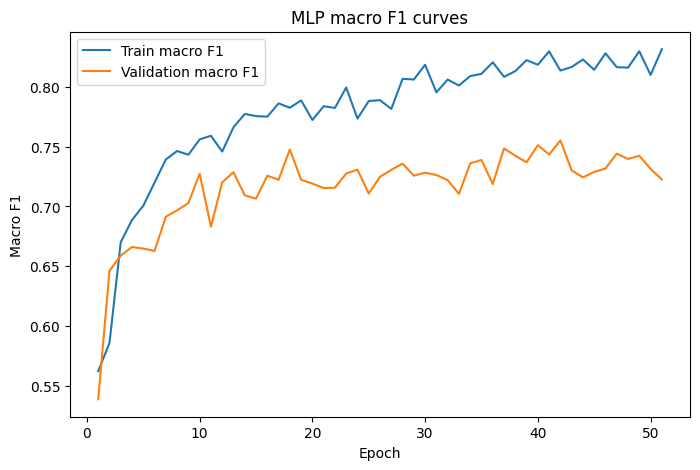

In [51]:
epochs_ran = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_ran, history["train_loss"], label="Train loss")
plt.plot(epochs_ran, history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MLP loss curves")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_ran, history["train_acc"], label="Train accuracy")
plt.plot(epochs_ran, history["val_acc"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MLP accuracy curves")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_ran, history["train_f1"], label="Train macro F1")
plt.plot(epochs_ran, history["val_f1"], label="Validation macro F1")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("MLP macro F1 curves")
plt.legend()
plt.show()

## Final evaluation on validation and test sets

The best saved model is evaluated on the validation set and then on the test set.

In [52]:
val_loss, val_acc, val_f1 = run_epoch(model, val_loader, criterion)
test_loss, test_acc, test_f1 = run_epoch(model, test_loader, criterion)

print(f"Validation loss: {val_loss:.4f}")
print(f"Validation accuracy: {val_acc:.4f}")
print(f"Validation macro F1: {val_f1:.4f}")

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test macro F1: {test_f1:.4f}")

Validation loss: 0.4923
Validation accuracy: 0.7320
Validation macro F1: 0.7188
Test loss: 0.4924
Test accuracy: 0.7055
Test macro F1: 0.6966


## Detailed test classification report

In [53]:
model.eval()

all_test_preds = []
all_test_targets = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = model(xb)
        preds = torch.argmax(logits, dim=1).cpu().numpy()

        all_test_preds.extend(preds)
        all_test_targets.extend(yb.numpy())

target_names = label_encoder.classes_.tolist()

print(classification_report(all_test_targets, all_test_preds, target_names=target_names))

              precision    recall  f1-score   support

           1       0.85      0.67      0.75       191
           2       0.55      0.77      0.64       101

    accuracy                           0.71       292
   macro avg       0.70      0.72      0.70       292
weighted avg       0.75      0.71      0.71       292



## Confusion matrix

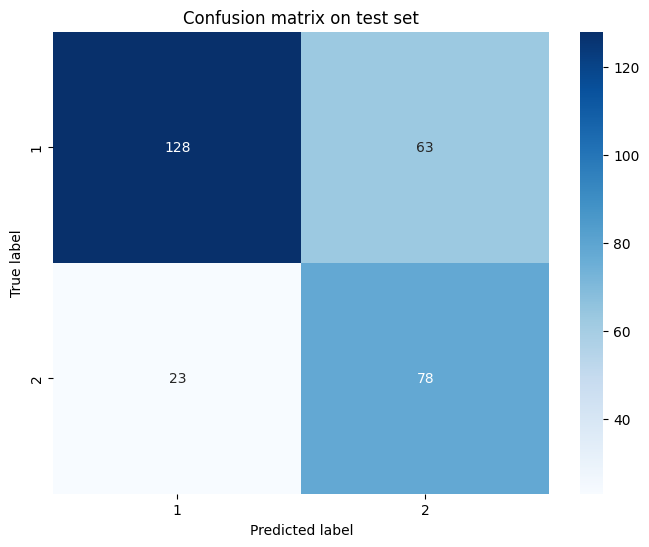

In [54]:
cm = confusion_matrix(all_test_targets, all_test_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion matrix on test set")
plt.show()

## Baseline MLP conclusion

The baseline MLP provides the first neural benchmark for the Steel Plates Faults dataset after preprocessing. The model uses standardized numerical inputs, weighted multiclass loss, and validation-based early stopping.

Its performance on the validation and test sets can now be used as a reference point for later improvements such as:
- hidden layer tuning
- dropout tuning
- learning-rate scheduling
- batch normalization
- deeper architectures
- alternative losses or regularization strategies

## Experiment tracking

The baseline MLP gives us a simple reference point, but it also raises the usual questions for tabular neural networks:
- is the model overfitting and would stronger regularization help?
- is optimization unstable and would normalization help training?
- is the hidden representation too wide and would a bottleneck improve generalization?
- if we make the network deeper, do skip connections help optimization?

To answer those questions, the experiments are arranged as a logical chain:
1. `dropout_mlp`: first increase regularization while keeping the architecture conceptually close to the baseline
2. `batchnorm_mlp`: then test whether normalization layers improve optimization stability and validation performance
3. `bottleneck_mlp`: if the wider normalized model learns useful features, test whether compressing them helps generalization
4. `skip_mlp` and `residual_mlp`: finally test skip connections in deeper architectures to see whether they improve optimization without hurting generalization

All experiments use the same train/validation/test split, the same class-weighted loss, and early stopping. This makes the comparison fair and suitable for the assignment report.

In [63]:
def train_experiment(model, train_loader, val_loader, optimizer, criterion, epochs=80, patience=12):
    history = {
        "train_loss": [],
        "train_acc": [],
        "train_f1": [],
        "val_loss": [],
        "val_acc": [],
        "val_f1": [],
    }

    best_state = None
    best_val_f1 = -float("inf")
    epochs_without_improvement = 0

    for epoch in range(1, epochs + 1):
        train_loss, train_acc, train_f1 = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc, val_f1 = run_epoch(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["train_f1"].append(train_f1)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_f1"].append(val_f1)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            break

    model.load_state_dict(best_state)
    return history


def collect_predictions(model, loader):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            logits = model(xb)
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_targets.extend(yb.numpy())

    return np.array(all_targets), np.array(all_preds)

### Step 1: stronger regularization with dropout

The first follow-up experiment should stay close to the baseline. If the baseline is overfitting, the simplest intervention is to increase regularization before changing the representation too much. That is why the first experiment uses a deeper MLP with stronger dropout.

In [ ]:
class DropoutMLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.35),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        return self.net(x)


### Step 2: stabilize training with Batch Normalization

If stronger dropout alone is not enough, the next logical step is to improve optimization. Dense networks on tabular data can be sensitive to activation scale, so Batch Normalization is tested next.

In [ ]:
class BatchNormMLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.net(x)


### Step 3: compress the representation with a bottleneck

Once the model can train more stably, it makes sense to ask whether it is learning a representation that is too wide. A bottleneck layer forces the network to keep only the most useful information, which can improve generalization.

In [ ]:
class BottleneckMLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(256, 96),
            nn.BatchNorm1d(96),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(96, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes),
        )

    def forward(self, x):
        return self.net(x)


### Step 4: test deeper models with skip connections

After regularization, normalization, and bottleneck compression, the final question is whether a deeper architecture helps. Deeper MLPs can be harder to optimize, so skip connections are added to test whether they preserve gradient flow and improve validation performance.

In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
        )
        self.activation = nn.ReLU()

    def forward(self, x):
        return self.activation(x + self.block(x))


class SkipMLPBlock(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout):
        super().__init__()
        self.main = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
        )
        self.shortcut = nn.Linear(input_dim, hidden_dim)
        self.activation = nn.ReLU()

    def forward(self, x):
        return self.activation(self.main(x) + self.shortcut(x))


class SkipMLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.block = SkipMLPBlock(input_dim, 128, dropout=0.20)
        self.head = nn.Sequential(
            nn.Dropout(0.20),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        x = self.block(x)
        return self.head(x)


class ResidualMLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.input_layer = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
        )
        self.block1 = ResidualBlock(128, dropout=0.20)
        self.block2 = ResidualBlock(128, dropout=0.20)
        self.head = nn.Sequential(
            nn.Dropout(0.20),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.input_layer(x)
        x = self.block1(x)
        x = self.block2(x)
        return self.head(x)


### Experiment registry

The models above are then registered in one place so the training loop can run them in the same order as the reasoning chain.

In [ ]:
def build_experiment_model(name, input_dim, num_classes):
    if name == "dropout_mlp":
        return DropoutMLP(input_dim, num_classes)
    if name == "batchnorm_mlp":
        return BatchNormMLP(input_dim, num_classes)
    if name == "bottleneck_mlp":
        return BottleneckMLP(input_dim, num_classes)
    if name == "skip_mlp":
        return SkipMLP(input_dim, num_classes)
    if name == "residual_mlp":
        return ResidualMLP(input_dim, num_classes)
    raise ValueError(f"Unknown experiment: {name}")


In [64]:
experiment_configs = [
    {
        "name": "batchnorm_mlp",
        "description": "Baseline width increase + BatchNorm for stabler optimization",
        "lr": 1e-3,
        "weight_decay": 1e-4,
        "epochs": 80,
        "patience": 12,
    },
    {
        "name": "dropout_mlp",
        "description": "Dropout regularization to reduce overfitting and improve generalization",
        "lr": 1e-3,
        "weight_decay": 1e-4,
        "epochs": 80,
        "patience": 12,
    },
    {
        "name": "bottleneck_mlp",
        "description": "Bottleneck hidden layer to encourage a more compact representation",
        "lr": 8e-4,
        "weight_decay": 1e-4,
        "epochs": 80,
        "patience": 12,
    },
    {
        "name": "skip_mlp",
        "description": "Skip connections to preserve earlier information and improve optimization",
        "lr": 8e-4,
        "weight_decay": 1e-4,
        "epochs": 90,
        "patience": 12,
    },
    {
        "name": "residual_mlp",
        "description": "Residual blocks to test a deeper architecture with skip connections",
        "lr": 7e-4,
        "weight_decay": 5e-4,
        "epochs": 100,
        "patience": 15,
    },
]

experiment_results = []
experiment_histories = {}
experiment_reports = {}

for config in experiment_configs:
    print(f"\nRunning {config['name']} ...")

    model = build_experiment_model(config["name"], input_dim, num_classes).to(device)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"],
    )
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

    history = train_experiment(
        model,
        train_loader,
        val_loader,
        optimizer,
        criterion,
        epochs=config["epochs"],
        patience=config["patience"],
    )

    val_loss, val_acc, val_f1 = run_epoch(model, val_loader, criterion)
    test_loss, test_acc, test_f1 = run_epoch(model, test_loader, criterion)
    test_targets, test_preds = collect_predictions(model, test_loader)

    experiment_histories[config["name"]] = history
    experiment_reports[config["name"]] = classification_report(
        test_targets,
        test_preds,
        target_names=target_names,
        output_dict=True,
        zero_division=0,
    )

    experiment_results.append({
        "experiment": config["name"],
        "description": config["description"],
        "epochs_ran": len(history["train_loss"]),
        "val_loss": val_loss,
        "val_acc": val_acc,
        "val_f1": val_f1,
        "test_loss": test_loss,
        "test_acc": test_acc,
        "test_f1": test_f1,
    })

results_df = pd.DataFrame(experiment_results).sort_values("val_f1", ascending=False)
results_df.style.format({
    "val_loss": "{:.4f}",
    "val_acc": "{:.4f}",
    "val_f1": "{:.4f}",
    "test_loss": "{:.4f}",
    "test_acc": "{:.4f}",
    "test_f1": "{:.4f}",
})


Running batchnorm_mlp ...

Running dropout_mlp ...

Running bottleneck_mlp ...

Running skip_mlp ...

Running residual_mlp ...


,experiment,description,epochs_ran,val_loss,val_acc,val_f1,test_loss,test_acc,test_f1
2,bottleneck_mlp,Bottleneck hidden layer to encourage a more compact representation,71,0.5597,0.7938,0.7692,0.5285,0.7397,0.7257
0,batchnorm_mlp,Baseline width increase + BatchNorm for stabler optimization,19,0.5104,0.7801,0.7574,0.5012,0.7363,0.7166
3,skip_mlp,Skip connections to preserve earlier information and improve optimization,21,0.5040,0.7801,0.7551,0.4936,0.7705,0.7524
4,residual_mlp,Residual blocks to test a deeper architecture with skip connections,30,0.5852,0.7766,0.7518,0.5432,0.7603,0.7457
1,dropout_mlp,Dropout regularization to reduce overfitting and improve generalization,30,0.5096,0.7732,0.7486,0.4984,0.7397,0.7197


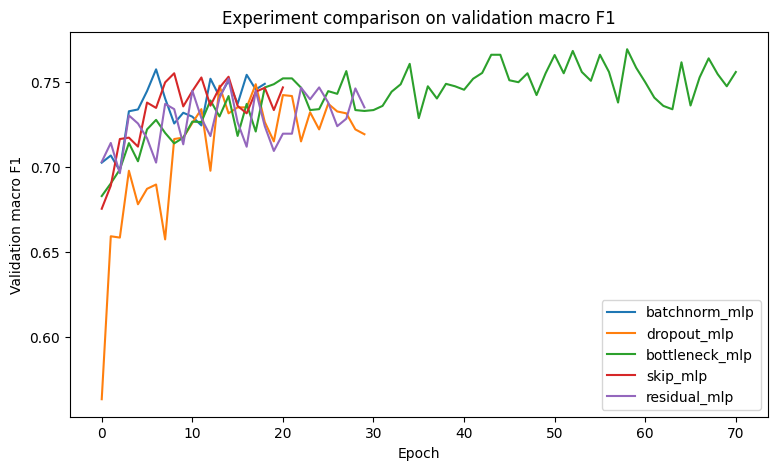

Best experiment based on validation macro F1:
experiment                                        bottleneck_mlp
description    Bottleneck hidden layer to encourage a more co...
val_f1                                                  0.769219
test_f1                                                 0.725713
Name: 2, dtype: object


In [65]:
plt.figure(figsize=(9, 5))

for row in experiment_results:
    name = row["experiment"]
    plt.plot(experiment_histories[name]["val_f1"], label=name)

plt.xlabel("Epoch")
plt.ylabel("Validation macro F1")
plt.title("Experiment comparison on validation macro F1")
plt.legend()
plt.show()

best_experiment = results_df.iloc[0]
print("Best experiment based on validation macro F1:")
print(best_experiment[["experiment", "description", "val_f1", "test_f1"]])
